In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import colors, cm
from mpl_toolkits.axes_grid1 import make_axes_locatable 
import matplotlib.colors as colors
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import matplotlib.image as mpimg
import pyproj
import warnings
from glob import glob
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

In [2]:
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings("ignore")

In [3]:
recovery = pd.read_csv("../../Recovery_Old.csv")
xx, yy = np.meshgrid(np.unique(recovery['x']), np.unique(recovery['y']))
velocity_x = recovery['velx_og'].values.reshape(xx.shape)
velocity_y = recovery['vely_og'].values.reshape(xx.shape)
bed = recovery['bed'].values.reshape(xx.shape)
surface_mass_balance = recovery['smb'].values.reshape(xx.shape)
surface_elevation_change = recovery['dhdt'].values.reshape(xx.shape)
ice_surface_elevation = recovery['surf'].values.reshape(xx.shape)
velocity_magnitude = np.sqrt(velocity_x**2 + velocity_y**2)
bedmap_bed = recovery['bedmap_bed'].values.reshape(xx.shape)
bedmachine_bed = recovery['bedmachine_bed'].values.reshape(xx.shape)
bedmachine_mask = recovery['bedmachine_mask'].values.reshape(xx.shape)
sgs_bed = np.loadtxt('../../sgs_new.txt').reshape(xx.shape)

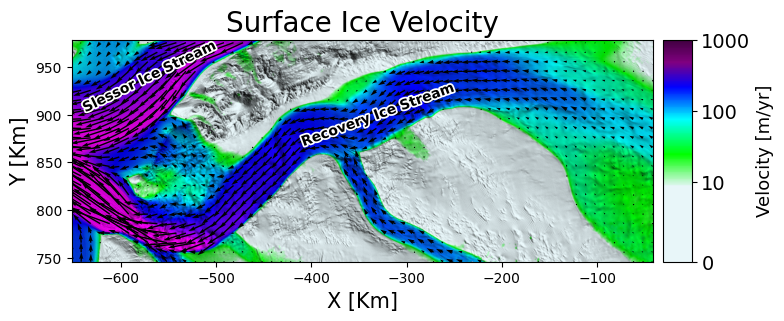

In [ ]:
velocity_magnitude = np.maximum(velocity_magnitude, 0)

xx = xx / 1000
yy = yy / 1000

vmax = 1000
vmin_colorbar = 0
linear_threshold = 10

colors_list = ["#E8F6F9", "lime", "cyan", "blue", "purple", "#400040"]
custom_cmap_nodes = [
    (0, colors_list[0]),
    (10, colors_list[0]),
    (30, colors_list[1]),
    (100, colors_list[2]),
    (300, colors_list[3]),
    (700, colors_list[4]),
    (1500, colors_list[5])
]

norm_for_cmap = colors.SymLogNorm(linthresh=linear_threshold, vmin=vmin_colorbar, vmax=np.maximum(vmax, 1500))
normalized_nodes = [(norm_for_cmap(val), color) for val, color in custom_cmap_nodes]
velocity_cmap = colors.LinearSegmentedColormap.from_list("custom_velocity", normalized_nodes)

plot_norm = colors.SymLogNorm(linthresh=linear_threshold, vmin=vmin_colorbar, vmax=vmax)

fig, ax = plt.subplots(figsize=(8, 6))

colored_velocity_image = velocity_cmap(plot_norm(velocity_magnitude))[:, :, :3]

ls = colors.LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(ice_surface_elevation, vert_exag=0.1, dx=1.0, dy=1.0)

hsv_colors = colors.rgb_to_hsv(colored_velocity_image)
hsv_colors[:, :, 2] = hillshade
rgb_blended = colors.hsv_to_rgb(hsv_colors)

ax.imshow(rgb_blended, extent=[xx.min(), xx.max(), yy.min(), yy.max()], origin='lower')
ax.set_title("Surface Ice Velocity", fontsize=20)
ax.set_xlabel('X [Km]', fontsize=15)
ax.set_ylabel('Y [Km]', fontsize=15)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

mappable = cm.ScalarMappable(norm=plot_norm, cmap=velocity_cmap)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical')
cbar.set_label("Velocity [m/yr]", fontsize=13)

cbar_ticks = [0, 10, 100, 1000]
cbar.set_ticks([t for t in cbar_ticks if t <= vmax])
cbar.set_ticklabels([str(t) for t in cbar_ticks if t <= vmax])
cbar.ax.tick_params(labelsize=14)
step = 20
velocity_subsampled = velocity_magnitude[::step, ::step]
mask = np.isfinite(velocity_subsampled) & (velocity_subsampled >= 10)
ax.quiver(xx[::step, ::step][mask], yy[::step, ::step][mask],
          velocity_x[::step, ::step][mask], velocity_y[::step, ::step][mask])

import matplotlib.patheffects as path_effects

common_props = {
    'fontweight': 'bold',
    'color': 'black',
    'ha': 'center',
    'va': 'center'
}

outline_effect = [path_effects.withStroke(linewidth=2.5, foreground='white')]

ax.text(-570, 940, 'Slessor Ice Stream', rotation=26, fontsize=10, **common_props, path_effects=outline_effect)
ax.text(-330, 900, 'Recovery Ice Stream', rotation=20, fontsize=10, **common_props, path_effects=outline_effect)
#plt.savefig("./final_plots/velocity.svg", format="svg", bbox_inches='tight')
plt.show()

xx *= 1000
yy *= 1000

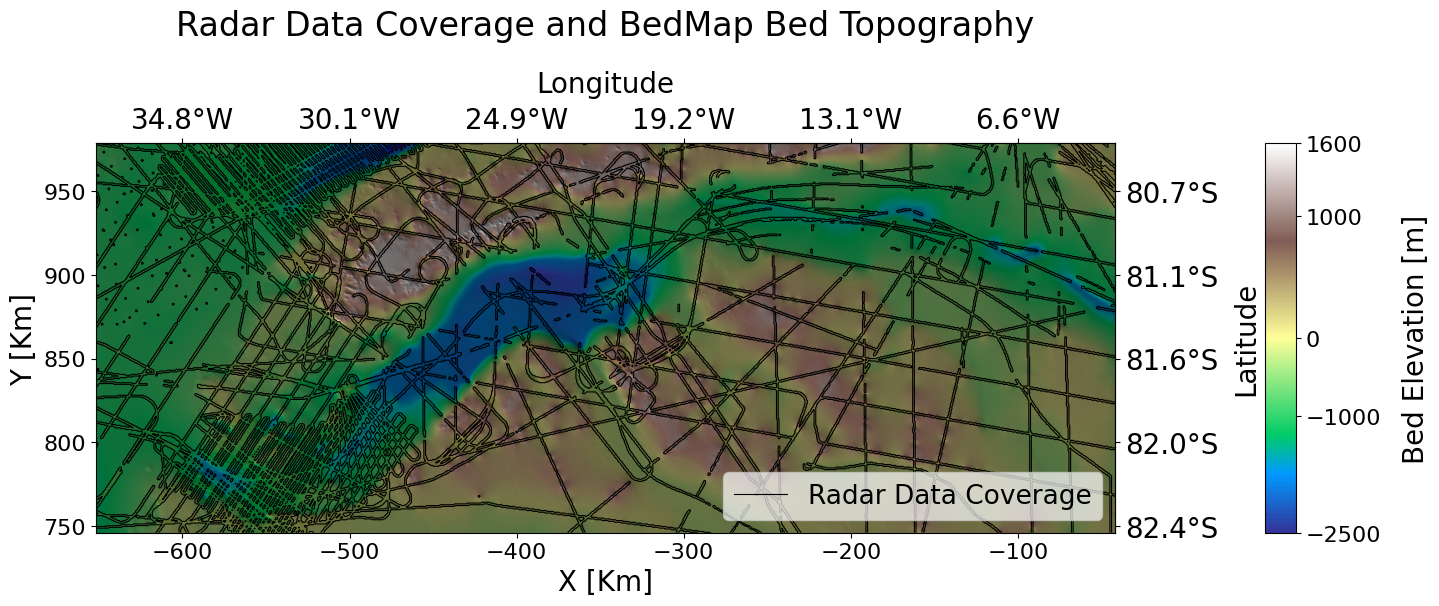

In [ ]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

original_cmap = get_cmap('terrain')

composite_bed = np.where(np.isnan(bed), bedmap_bed, bed)
radar_mask = ~np.isnan(bed)

xx_km = xx / 1000
yy_km = yy / 1000
vmin = -2500
vmax = 1600

terrain_cmap = plt.get_cmap('terrain')
norm = colors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

ls = colors.LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(bedmap_bed, vert_exag=0.05, dx=np.diff(xx[0, :]).mean(), dy=np.diff(yy[:, 0]).mean())

colored_bedrock_image = terrain_cmap(norm(composite_bed))[:, :, :3]
hsv_colors = colors.rgb_to_hsv(colored_bedrock_image)
hsv_colors[radar_mask, 1] = np.clip(hsv_colors[radar_mask, 1] * 1.3, 0, 1)
hsv_colors[:, :, 2] = hillshade
rgb_blended = colors.hsv_to_rgb(hsv_colors)

fig, ax = plt.subplots(figsize=(15, 12))
fig.subplots_adjust(bottom=0.1, top=0.88, left=0.1) 

ax.imshow(rgb_blended, extent=[xx_km.min(), xx_km.max(), yy_km.min(), yy_km.max()], origin='lower')
ax.contour(xx_km, yy_km, radar_mask, levels=[0.5], colors='black', linewidths=0.8)

ax.set_title("Radar Data Coverage and BedMap Bed Topography", fontsize=24, pad=25)
ax.set_xlabel('X [Km]', fontsize=20)
ax.set_ylabel('Y [Km]', fontsize=20)
ax.tick_params(labelsize=16)


proj_ps = pyproj.Proj('epsg:3031')
proj_latlon = pyproj.Proj('epsg:4326')
transformer = pyproj.Transformer.from_proj(proj_ps, proj_latlon, always_xy=True)

def psx_to_lon(x_km):
    x_m = x_km * 1000
    y_m = np.full_like(x_m, (yy.min() + yy.max()) / 2)
    lons, _ = transformer.transform(x_m, y_m)
    return lons

def psy_to_lat(y_km):
    y_m = y_km * 1000
    x_m = np.full_like(y_m, (xx.min() + xx.max()) / 2)
    _, lats = transformer.transform(x_m, y_m)
    return lats

secax_x = ax.secondary_xaxis('top')
secax_y = ax.secondary_yaxis('right')

xticks_km = ax.get_xticks()
yticks_km = ax.get_yticks()

secax_x.set_xticks(xticks_km)
secax_x.set_xticklabels([f'{-lon:.1f}°W' for lon in psx_to_lon(xticks_km)]) 
secax_y.set_yticks(yticks_km)
secax_y.set_yticklabels([f'{-lat:.1f}°S' for lat in psy_to_lat(yticks_km)]) 

secax_x.set_xlabel('Longitude', fontsize=20, labelpad=10)
secax_y.set_ylabel('Latitude', fontsize=20, labelpad=10)
secax_x.tick_params(labelsize=20)
secax_y.tick_params(labelsize=20)

divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="3%", pad=1.5) 

mappable = cm.ScalarMappable(norm=norm, cmap=terrain_cmap)

cbar = fig.colorbar(mappable, cax=cax, orientation='vertical') 
cbar.set_label("Bed Elevation [m]", fontsize=20, labelpad=15)
cbar_ticks = [-2500, -1000, 0, 1000, 1600]
cbar.set_ticks(cbar_ticks)
cbar.ax.tick_params(labelsize=16)

legend_elements = [Line2D([0], [0], color='black', lw=0.8, label='Radar Data Coverage')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=19, frameon=True, facecolor='w', framealpha=0.7)

#plt.savefig("./final_plots/radar.svg", format="svg", bbox_inches='tight')

plt.show()

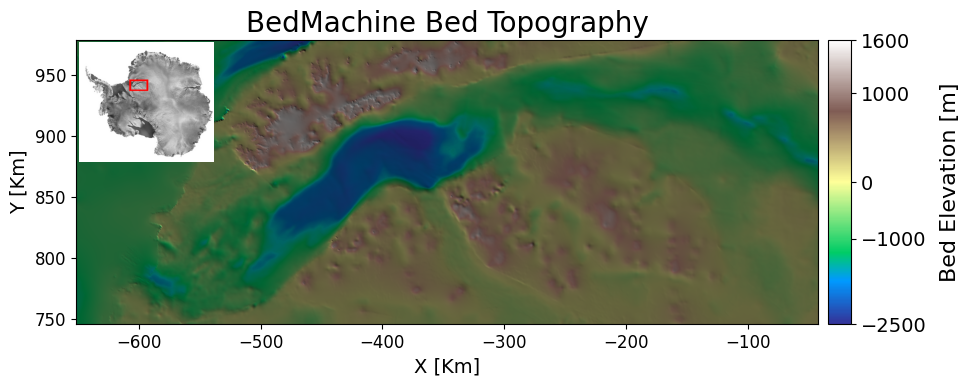

In [ ]:
terrain_cmap = plt.get_cmap('terrain')
norm = colors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

ls = colors.LightSource(azdeg=315, altdeg=45)
dx = np.abs(xx[0, 1] - xx[0, 0])
dy = np.abs(yy[1, 0] - yy[0, 0])
hillshade = ls.hillshade(bedmachine_bed, vert_exag=0.05, dx=dx, dy=dy)

colored_bedrock_image = terrain_cmap(norm(bedmachine_bed))[:, :, :3]
hsv_colors = colors.rgb_to_hsv(colored_bedrock_image)
hsv_colors[:, :, 2] = hillshade
rgb_blended = colors.hsv_to_rgb(hsv_colors)

fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(rgb_blended, extent=[xx_km.min(), xx_km.max(), yy_km.min(), yy_km.max()], origin='lower')

ax.set_title("BedMachine Bed Topography", fontsize=20)
ax.set_xlabel('X [Km]', fontsize=14)
ax.set_ylabel('Y [Km]', fontsize=14)
ax.tick_params(labelsize=12)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

mappable = cm.ScalarMappable(norm=norm, cmap=terrain_cmap)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical')
cbar.set_label("Bed Elevation [m]", fontsize=16, labelpad=10)

cbar_ticks = [-2500, -1000, 0, 1000, 1600]
cbar.set_ticks(cbar_ticks)
cbar.ax.tick_params(labelsize=14)


img = mpimg.imread("antartica_1.jpg")

ax_inset = fig.add_axes([0.12, 0.52, 0.15, 0.15], zorder=10)

ax_inset.imshow(img)
ax_inset.axis('off') 

#plt.savefig("./final_plots/bedmachine.svg", format="svg", bbox_inches='tight')

plt.show()

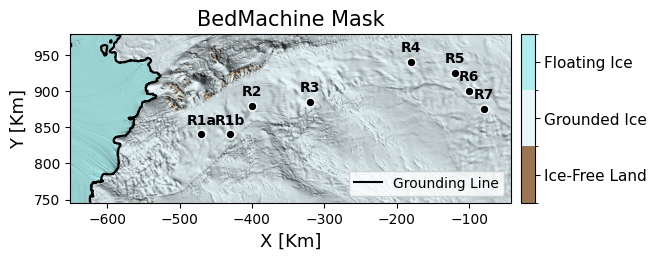

In [ ]:
xx_km = xx / 1000
yy_km = yy / 1000

mask_colors_dict = {
    0: 'royalblue',     
    1: '#9B7653',            
    2: '#E8F6F9',     
    3: 'paleturquoise'   
}
mask_labels_dict = {
    0: 'Ocean',
    1: 'Ice-Free Land',
    2: 'Grounded Ice',
    3: 'Floating Ice'
}

unique_mask_vals = np.unique(bedmachine_mask)
cmap_list = [mask_colors_dict.get(val, 'gray') for val in unique_mask_vals]

custom_mask_cmap = colors.ListedColormap(cmap_list)
bounds = np.append(unique_mask_vals, unique_mask_vals.max() + 1)
norm_for_mask = colors.BoundaryNorm(boundaries=bounds, ncolors=custom_mask_cmap.N)

colored_mask_image = custom_mask_cmap(norm_for_mask(bedmachine_mask))[:, :, :3]

ls = colors.LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(ice_surface_elevation, vert_exag=0.1, dx=1.0, dy=1.0)

hsv_colors = colors.rgb_to_hsv(colored_mask_image)
hsv_colors[:, :, 2] = hillshade
rgb_blended = colors.hsv_to_rgb(hsv_colors)

fig, ax = plt.subplots(figsize=(6, 8))

ax.imshow(rgb_blended, extent=[xx_km.min(), xx_km.max(), yy_km.min(), yy_km.max()], origin='lower')

ax.set_title("BedMachine Mask", fontsize=15)
ax.set_xlabel('X [Km]', fontsize=13)
ax.set_ylabel('Y [Km]', fontsize=13)

ax.contour(
    xx_km,
    yy_km,
    bedmachine_mask,
    levels=[2.5],
    colors='black',
    linewidths=1.5
)

grounding_line_proxy = Line2D(
    [0], [0], 
    label='Grounding Line',
    color='black',
    linewidth=1.5,
)
ax.legend(handles=[grounding_line_proxy], loc='lower right', fontsize=10)


divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="3%", pad=0.1) 

mappable = cm.ScalarMappable(norm=norm_for_mask, cmap=custom_mask_cmap)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical')

tick_locs = unique_mask_vals + 0.5
tick_labels = [mask_labels_dict.get(val, 'Unknown') for val in unique_mask_vals]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)
cbar.ax.tick_params(labelsize=11)
lake_locations = {
    'R1a': (-470, 840), 'R1b': (-430, 840), 'R2': (-400, 880),
    'R3': (-320, 885), 'R4': (-180, 940), 'R5': (-120, 925),
    'R6': (-100, 900), 'R7': (-80, 875)
}
for name, (x, y) in lake_locations.items():
    ax.scatter(x, y, color='black', s=40, zorder=5, edgecolor='white')
    ax.text(x, y + 10, name, color='black', fontsize=10, ha='center', va='bottom',
            fontweight='bold')

plt.savefig("./final_plots/mask.svg", format="svg", bbox_inches='tight')

plt.show()

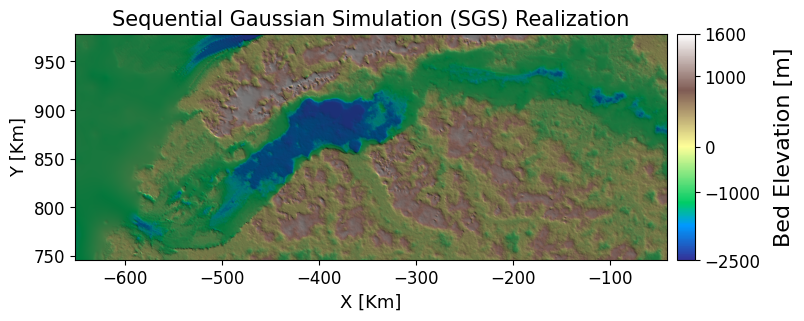

In [8]:
terrain_cmap = plt.get_cmap('terrain')
norm = colors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

ls = colors.LightSource(azdeg=315, altdeg=45)
dx = np.abs(xx[0, 1] - xx[0, 0])
dy = np.abs(yy[1, 0] - yy[0, 0])
hillshade = ls.hillshade(sgs_bed, vert_exag=0.05, dx=dx, dy=dy)

colored_bedrock_image = terrain_cmap(norm(sgs_bed))[:, :, :3]
hsv_colors = colors.rgb_to_hsv(colored_bedrock_image)
hsv_colors[:, :, 2] = hillshade
rgb_blended = colors.hsv_to_rgb(hsv_colors)

fig, ax = plt.subplots(figsize=(8, 6))

ax.imshow(rgb_blended, extent=[xx_km.min(), xx_km.max(), yy_km.min(), yy_km.max()], origin='lower')

ax.set_title("Sequential Gaussian Simulation (SGS) Realization", fontsize=15)
ax.set_xlabel('X [Km]', fontsize=13)
ax.set_ylabel('Y [Km]', fontsize=13)
ax.tick_params(labelsize=12)


divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="3%", pad=0.1)

mappable = cm.ScalarMappable(norm=norm, cmap=terrain_cmap)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical')
cbar.set_label("Bed Elevation [m]", fontsize=16, labelpad=10)

cbar_ticks = [-2500, -1000, 0, 1000, 1600]
cbar.set_ticks(cbar_ticks)
cbar.ax.tick_params(labelsize=12)

plt.savefig("./final_plots/sgs.svg", format="svg", bbox_inches='tight')

plt.show()

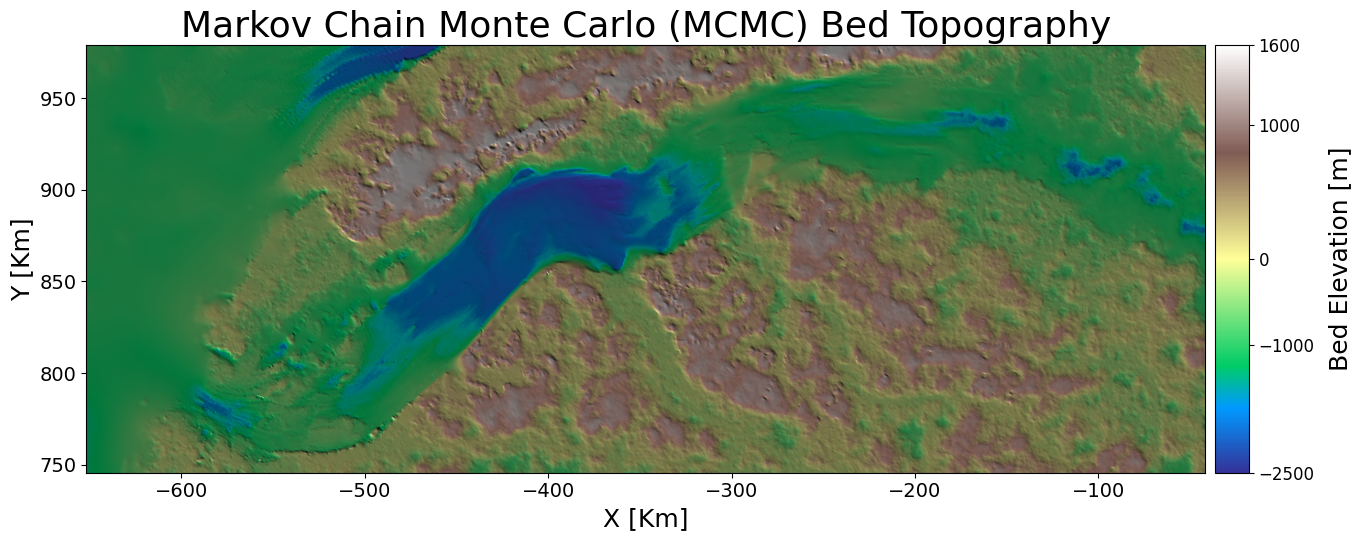

In [9]:
mcmc_bed = np.loadtxt('../../geostatisticalMCMC/trial_21/beds/bed100000.txt')
terrain_cmap = plt.get_cmap('terrain')
norm = colors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

ls = colors.LightSource(azdeg=315, altdeg=45)
dx = np.abs(xx[0, 1] - xx[0, 0])
dy = np.abs(yy[1, 0] - yy[0, 0])
hillshade = ls.hillshade(mcmc_bed, vert_exag=0.05, dx=dx, dy=dy)

colored_bedrock_image = terrain_cmap(norm(mcmc_bed))[:, :, :3]
hsv_colors = colors.rgb_to_hsv(colored_bedrock_image)
hsv_colors[:, :, 2] = hillshade
rgb_blended = colors.hsv_to_rgb(hsv_colors)

fig, ax = plt.subplots(figsize=(15, 10))

ax.imshow(rgb_blended, extent=[xx_km.min(), xx_km.max(), yy_km.min(), yy_km.max()], origin='lower')

ax.set_title("Markov Chain Monte Carlo (MCMC) Bed Topography", fontsize=26)
ax.set_xlabel('X [Km]', fontsize=18)
ax.set_ylabel('Y [Km]', fontsize=18)
ax.tick_params(labelsize=14)


divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="3%", pad=0.1)

mappable = cm.ScalarMappable(norm=norm, cmap=terrain_cmap)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical')
cbar.set_label("Bed Elevation [m]", fontsize=18, labelpad=10)

cbar_ticks = [-2500, -1000, 0, 1000, 1600]
cbar.set_ticks(cbar_ticks)
cbar.ax.tick_params(labelsize=12)

plt.savefig("./final_plots/mcmc.svg", format="svg", bbox_inches='tight')
plt.show()

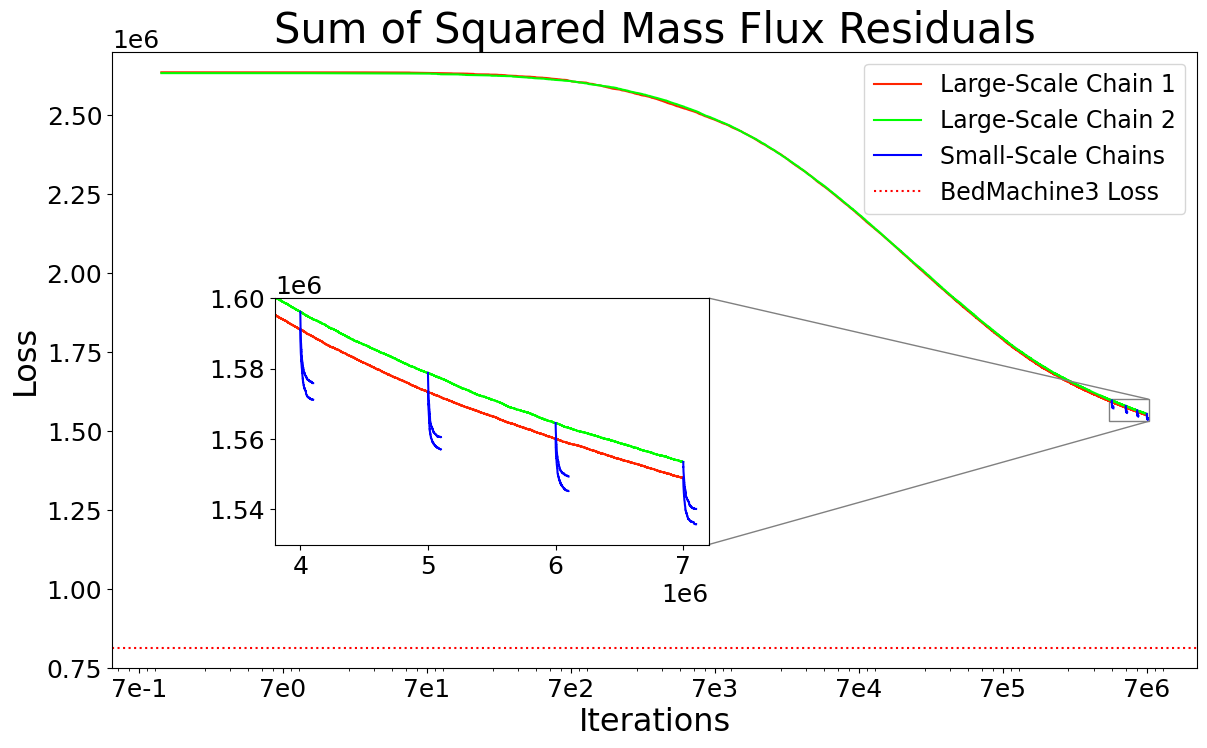

In [10]:
plt.rcParams['font.size'] = 18
tick_locs = np.array([7e-1, 7e0, 7e1, 7e2, 7e3, 7e4, 7e5, 7e6])
large_loss = glob('../../geostatisticalMCMC/trial_1/loss/*.txt')
iters1 = np.array(pd.Series(large_loss).str.split('/').str[-1].str[4:].str[:-4].astype(int).sort_values())
iters2 = np.arange(0, 101_000, 1000)
indices = np.arange(5000, iters1[-1] + 5000, 5000)

large_loss1 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_1/loss/loss' + str(i) + '.txt') for i in indices])
large_loss2 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_2/loss/loss' + str(i) + '.txt') for i in indices])
small_loss11 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_11/loss/loss' + str(i) + '.txt') for i in iters2])
small_loss12 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_12/loss/loss' + str(i) + '.txt') for i in iters2])
small_loss13 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_13/loss/loss' + str(i) + '.txt') for i in iters2])
small_loss14 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_14/loss/loss' + str(i) + '.txt') for i in iters2])
small_loss21 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_21/loss/loss' + str(i) + '.txt') for i in iters2])
small_loss22 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_22/loss/loss' + str(i) + '.txt') for i in iters2])
small_loss23 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_23/loss/loss' + str(i) + '.txt') for i in iters2])
small_loss24 = np.concatenate([np.loadtxt('../../geostatisticalMCMC/trial_24/loss/loss' + str(i) + '.txt') for i in iters2])

X1 = np.arange(1, len(large_loss1) + 1)
X2 = np.arange(1, len(large_loss2) + 1)
X11 = np.arange(7e6, len(small_loss11) + 7e6)
X12 = np.arange(6e6, len(small_loss11) + 6e6)
X13 = np.arange(5e6, len(small_loss11) + 5e6)
X14 = np.arange(4e6, len(small_loss11) + 4e6)
X21 = np.arange(7e6, len(small_loss11) + 7e6)
X22 = np.arange(6e6, len(small_loss11) + 6e6)
X23 = np.arange(5e6, len(small_loss11) + 5e6)
X24 = np.arange(4e6, len(small_loss11) + 4e6)

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(X1, large_loss1, c="#FF2400", label="Large-Scale Chain 1")
ax.plot(X2, large_loss2, c="lime", label="Large-Scale Chain 2")
ax.plot(X11, small_loss11, c='blue', label="Small-Scale Chains")
ax.plot(X12, small_loss12, c='blue')
ax.plot(X13, small_loss13, c='blue')
ax.plot(X14, small_loss14, c='blue')
ax.plot(X21, small_loss21, c='blue')
ax.plot(X22, small_loss22, c='blue')
ax.plot(X23, small_loss23, c='blue')
ax.plot(X24, small_loss24, c='blue')

ax.set_xscale('log')
axins = ax.inset_axes([0.15, 0.2, 0.4, 0.4])

axins.plot(X1, large_loss1, c="#FF2400")
axins.plot(X2, large_loss2, c="lime")
axins.plot(X11, small_loss11, c='blue')
axins.plot(X12, small_loss12, c='blue')
axins.plot(X13, small_loss13, c='blue')
axins.plot(X14, small_loss14, c='blue')
axins.plot(X21, small_loss21, c='blue')
axins.plot(X22, small_loss22, c='blue')
axins.plot(X23, small_loss23, c='blue')
axins.plot(X24, small_loss24, c='blue')
axins.tick_params(labelsize=18)

ax.axhline(y=811538, linestyle=':', color='red', label="BedMachine3 Loss")

x1, x2 = 3_800_000, 7_200_000
axins.set_xlim(x1, x2)

y_min_target = 1.53e6
y_max_target = 1.6e6
axins.set_ylim(y_min_target, y_max_target)

mark_inset(ax, axins, loc1=1, loc2=4, fc="none", ec="0.5")

ax.set_xticks(tick_locs)
custom_labels = np.array(['7e-1', '7e0', '7e1', '7e2', '7e3', '7e4', '7e5', '7e6'])
ax.set_xticklabels(custom_labels)
ax.set_ylim(0.75e6, 2.70e6)

ax.set_xlabel('Iterations', fontsize=23)
ax.set_ylabel('Loss', fontsize=23)
ax.set_title('Sum of Squared Mass Flux Residuals', fontsize=30)
ax.legend(fontsize=17)
ax.tick_params(labelsize=18)

plt.savefig("./final_plots/loss.svg", format="svg", bbox_inches='tight')

plt.show()

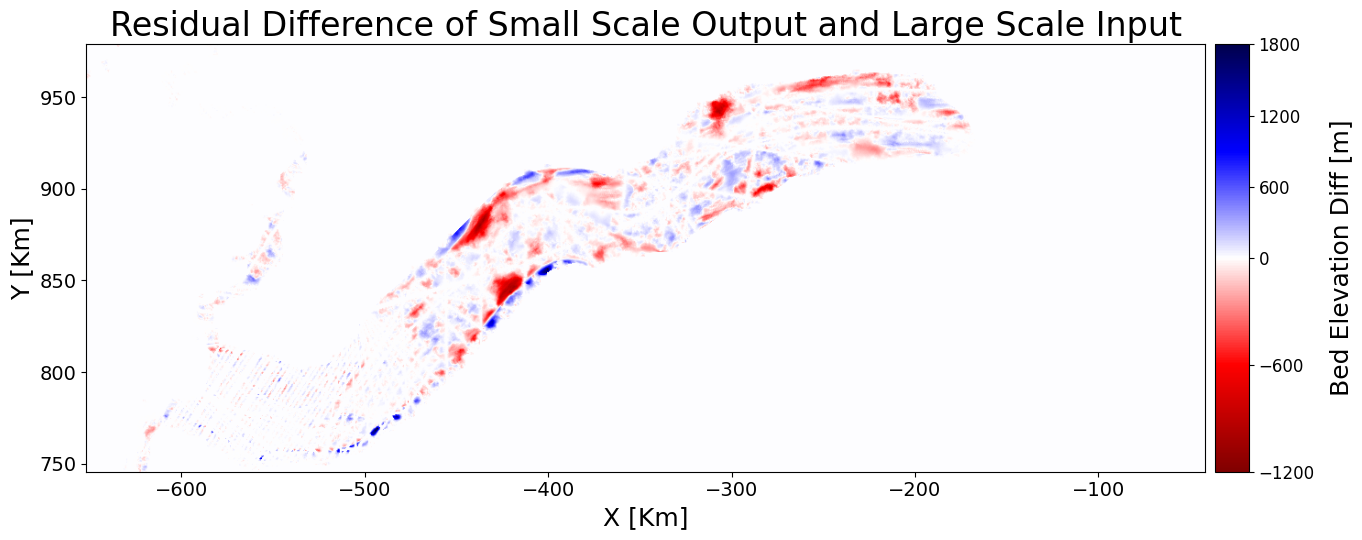

In [ ]:
diff_bed = np.loadtxt('../../geostatisticalMCMC/trial_21/beds/bed35000.txt') - np.loadtxt('../../geostatisticalMCMC/trial_2/beds/bed0.txt')

terrain_cmap = plt.get_cmap('seismic_r') 
norm = colors.TwoSlopeNorm(vcenter=0, vmin=-1200, vmax=1800)

ls = colors.LightSource(azdeg=315, altdeg=45)
dx = np.abs(xx[0, 1] - xx[0, 0])
dy = np.abs(yy[1, 0] - yy[0, 0])

rgb_blended = ls.shade(diff_bed, cmap=terrain_cmap, norm=norm, vert_exag=0.05, dx=dx, dy=dy, blend_mode='overlay')

fig, ax = plt.subplots(figsize=(15, 10))

ax.imshow(rgb_blended, extent=[xx_km.min(), xx_km.max(), yy_km.min(), yy_km.max()], origin='lower')

ax.set_title("Residual Difference of Small Scale Output and Large Scale Input", fontsize=24)
ax.set_xlabel('X [Km]', fontsize=18)
ax.set_ylabel('Y [Km]', fontsize=18)
ax.tick_params(labelsize=14)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

mappable = cm.ScalarMappable(norm=norm, cmap=terrain_cmap)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical')
cbar.set_label("Bed Elevation Diff [m]", fontsize=18, labelpad=10)

cbar_ticks = [-1200, -600, 0, 600, 1200, 1800]
cbar.set_ticks(cbar_ticks)
cbar.ax.tick_params(labelsize=12)

plt.savefig("./final_plots/diff.svg", format="svg", bbox_inches='tight')
plt.show()